# Q3: Pathway-Signaling ODE Model of Anti-EGFR Response in CRC

In [1]:
## Import data

import pandas as pd
df = pd.read_csv("../data/raw/sourcedata_fig4a_fig5.csv")
# print(df.columns.tolist())
# print(df.head())

egfr = df[df['Unnamed: 0'] == 'P00533']

# pick one cell line, e.g. HCT
cols = [c for c in df.columns if c.startswith('HCT_OS_')]
timepoints = ['5min','15min','1h','6h','24h','48h','96h']
cols_ordered = [f'HCT_OS_{t}' for t in timepoints]

egfr_trace = egfr[cols_ordered].values.flatten()
print(dict(zip(timepoints, egfr_trace)))

{'5min': np.float64(-0.389967578597161), '15min': np.float64(-0.22426134764253), '1h': np.float64(-0.773984814897985), '6h': np.float64(-0.811480509019251), '24h': np.float64(-0.862828058628247), '48h': np.float64(0.587360392101448), '96h': np.float64(0.943444817681168)}


In [2]:
import numpy as np

hours = {'5min': 5/60, '15min': 15/60, '1h': 1, '6h': 6, '24h': 24, '48h': 48, '96h': 96}
t = np.array(list(hours.values()))

os_trace = egfr[[f'HCT_OS_{k}' for k in hours]].values.flatten()
control_trace = egfr[[f'HCT_C_{k}' for k in hours]].values.flatten()

drug_effect = os_trace - control_trace   # isolates the drug's effect from baseline noise
print(dict(zip(hours.keys(), drug_effect)))

{'5min': np.float64(-0.3474820036601207), '15min': np.float64(-0.591180241516746), '1h': np.float64(-0.332022564736207), '6h': np.float64(-1.321592463171893), '24h': np.float64(-1.489979878168116), '48h': np.float64(1.282081538573443), '96h': np.float64(0.2692536002023229)}


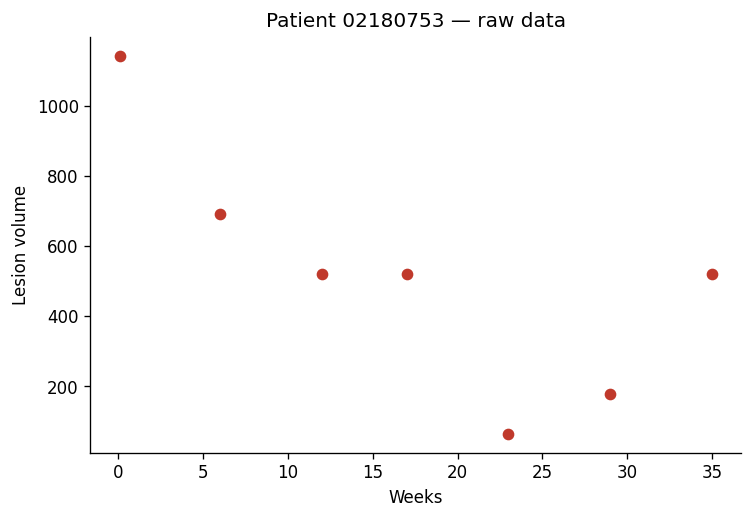

r=3.5963, k=3.7011, k_elim=0.0012


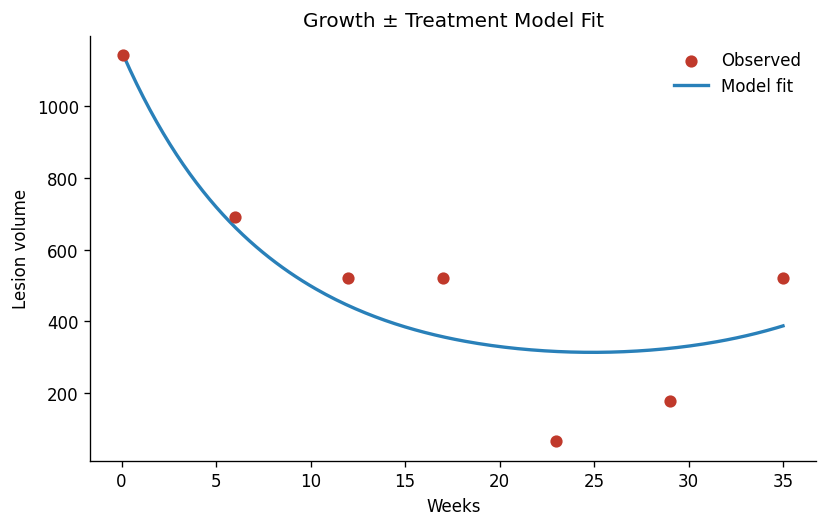

In [3]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 1. Load & pick one patient ---
df = pd.read_csv("../data/raw/flat_patient_data.csv")

patient_id = df["Pt_hashID"].iloc[0]          # swap for any patient hash
pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")

data_time = pt["T_weeks"].values
data_volume = pt["Lesion_vol"].values

# --- 2. Plot raw data ---
fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.scatter(data_time, data_volume, color='#c0392b', label='Observed')
ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
ax.set_title(f'Patient {patient_id[:8]} — raw data')
ax.spines[['top','right']].set_visible(False)
plt.show()

# --- 3. ODE system ---
def growth_treatment(t, y, r, k, k_elim):
    T, C = y
    dTdt = r*T - k*C*T
    dCdt = -k_elim*C
    return [dTdt, dCdt]

def simulate(t_eval, r, k, k_elim, T0, C0=1.0):
    sol = solve_ivp(growth_treatment, [t_eval[0], t_eval[-1]], [T0, C0],
                     args=(r, k, k_elim), t_eval=t_eval, method='RK45')
    return sol.y[0]

def fit_func(t, r, k, k_elim):
    return simulate(t, r, k, k_elim, T0=data_volume[0])

# --- 4. Fit ---
popt, pcov = curve_fit(fit_func, data_time, data_volume,
                        p0=[0.05, 0.05, 0.05], bounds=(0, np.inf), maxfev=10000)
r_fit, k_fit, k_elim_fit = popt
print(f"r={r_fit:.4f}, k={k_fit:.4f}, k_elim={k_elim_fit:.4f}")

# --- 5. Plot fit vs data ---
t_smooth = np.linspace(data_time.min(), data_time.max(), 200)
fitted_smooth = simulate(t_smooth, r_fit, k_fit, k_elim_fit, T0=data_volume[0])

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.scatter(data_time, data_volume, color='#c0392b', label='Observed', zorder=3, s=40)
ax.plot(t_smooth, fitted_smooth, color='#2980b9', label='Model fit', linewidth=2)
ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
ax.set_title('Growth ± Treatment Model Fit')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/model1_fit.png', dpi=150)
plt.show()

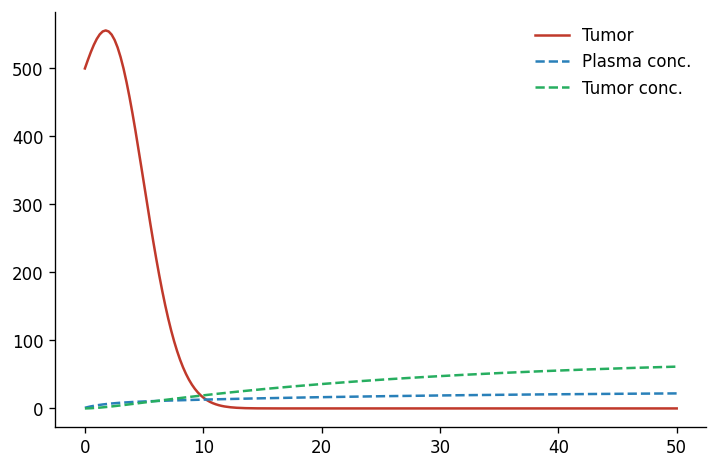

In [4]:
def pk_infiltration(t, y, k12, k21, k_elim, dose_rate):
    T, C_plasma, C_tumor = y
    dTdt = 0.1*T - 0.05*C_tumor*T
    dCp = dose_rate - k_elim*C_plasma - k12*C_plasma + k21*C_tumor
    dCt = k12*C_plasma - k21*C_tumor
    return [dTdt, dCp, dCt]

sol = solve_ivp(pk_infiltration, [0, 50], [500, 1, 0],
                 args=(0.3, 0.1, 0.2, 5), t_eval=np.linspace(0, 50, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.plot(sol.t, sol.y[0], label='Tumor', color='#c0392b')
ax.plot(sol.t, sol.y[1], label='Plasma conc.', color='#2980b9', linestyle='--')
ax.plot(sol.t, sol.y[2], label='Tumor conc.', color='#27ae60', linestyle='--')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.savefig('../outputs/pkInfiltration', dpi=150)
plt.show()

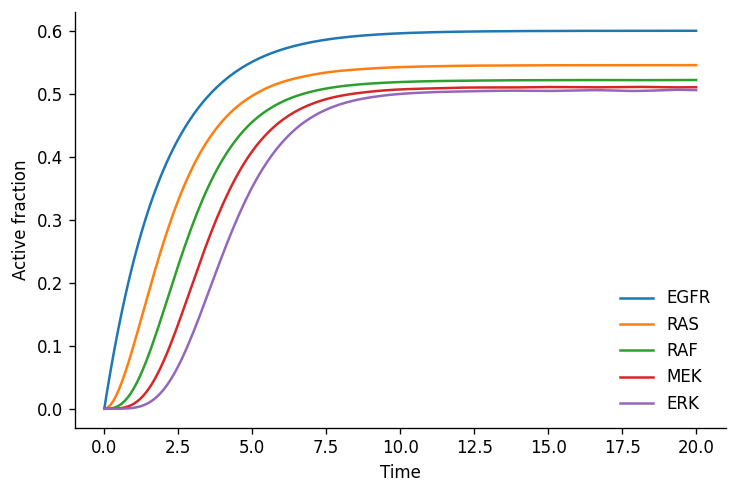

In [5]:
# --- Model 3: Pathway inhibition ---
def pathway(t, y, I=0.7):
    EGFR, RAS, RAF, MEK, ERK = y
    k, d = 1.0, 0.5
    dEGFR = k*(1-I) - d*EGFR
    dRAS  = k*EGFR*(1-RAS) - d*RAS
    dRAF  = k*RAS*(1-RAF) - d*RAF
    dMEK  = k*RAF*(1-MEK) - d*MEK
    dERK  = k*MEK*(1-ERK) - d*ERK
    return [dEGFR, dRAS, dRAF, dMEK, dERK]

sol3 = solve_ivp(pathway, [0, 20], [0,0,0,0,0], t_eval=np.linspace(0, 20, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
for i, name in enumerate(['EGFR','RAS','RAF','MEK','ERK']):
    ax.plot(sol3.t, sol3.y[i], label=name)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_xlabel('Time'); ax.set_ylabel('Active fraction')
plt.savefig('../outputs/PathwayInbibition', dpi=150)
plt.show()

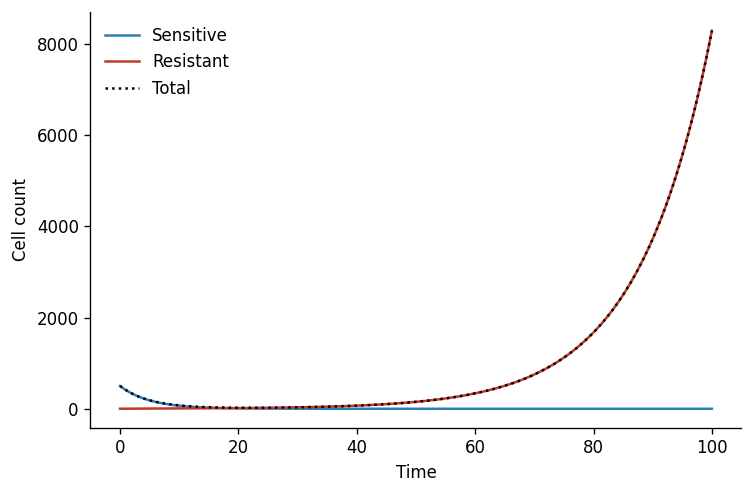

In [6]:
# --- Model 4: Resistance emergence ---
def resistance(t, y, r_s=0.1, r_r=0.08, k=0.3, mu=0.001):
    S, R = y
    dS = r_s*S - k*S - mu*S
    dR = r_r*R + mu*S
    return [dS, dR]

sol4 = solve_ivp(resistance, [0, 100], [500, 1], t_eval=np.linspace(0, 100, 200))

fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
ax.plot(sol4.t, sol4.y[0], label='Sensitive', color='#2980b9')
ax.plot(sol4.t, sol4.y[1], label='Resistant', color='#c0392b')
ax.plot(sol4.t, sol4.y[0]+sol4.y[1], label='Total', color='black', linestyle=':')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_xlabel('Time'); ax.set_ylabel('Cell count')
plt.savefig('../outputs/ResistanceEmergence', dpi=150)
plt.show()

In [7]:
# --- List patients ---
patients = df["Pt_hashID"].unique()
print(f"{len(patients)} patients")
print(patients[:10])

# --- Reusable per-patient fit function ---
def fit_patient(patient_id, df):
    pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")
    pt = pt.dropna(subset=["T_weeks", "Lesion_vol"])
    pt = pt.drop_duplicates(subset="T_weeks")   # <-- fixes the sort error
    t, v = pt["T_weeks"].values, pt["Lesion_vol"].values

    if len(t) < 4:
        return None

    def fit_func(t, r, k, k_elim):
        return simulate(t, r, k, k_elim, T0=v[0])

    try:
        popt, _ = curve_fit(fit_func, t, v, p0=[0.05, 0.05, 0.05],
                             bounds=(0, np.inf), maxfev=10000)
        return {"patient": patient_id, "r": popt[0], "k": popt[1],
                "k_elim": popt[2], "n_points": len(t)}
    except RuntimeError:
        return None

# --- Run across all patients ---
results = []
for pid in patients:
    res = fit_patient(pid, df)
    if res:
        results.append(res)

results_df = pd.DataFrame(results)
print(f"Fitted {len(results_df)}/{len(patients)} patients")
results_df.head()

1461 patients
['0218075314855e6ceacca856fcd4c737-S1'
 '19ce84cc1b10000b63820280995107c2-S1'
 '2eb9b56bf51cdba056d9bc629b4a7beb-S1'
 '392c2c5db81b3544737f8f4612faaf5d-S1'
 '4edce4029c44125f5643ba97531e987b-S1'
 '506309f5c81d475e8750680ebb752419-S1'
 '5462aa2b40f5b9a0a8b3a18980223ebd-S1'
 '5aabae34c493ef88ce07cc133acade7f-S1'
 '6ea20ad7ed5a675d8a9df5b59e287023-S1'
 '801aa6775f69bd009eb1b3243f36c208-S1']
Fitted 1058/1461 patients


,patient,r,k,k_elim,n_points
0,0218075314855e6ceacca856fcd4c737-S1,3.596275e+00,3.701094,1.158462e-03,7
1,19ce84cc1b10000b63820280995107c2-S1,5.551554e-19,0.251989,1.516583e-01,6
2,2eb9b56bf51cdba056d9bc629b4a7beb-S1,3.582541e-07,0.088230,1.780251e-08,6
3,4edce4029c44125f5643ba97531e987b-S1,3.731196e+01,37.371754,2.448587e-04,5
4,506309f5c81d475e8750680ebb752419-S1,6.948549e-02,4.395387,1.056043e-01,8


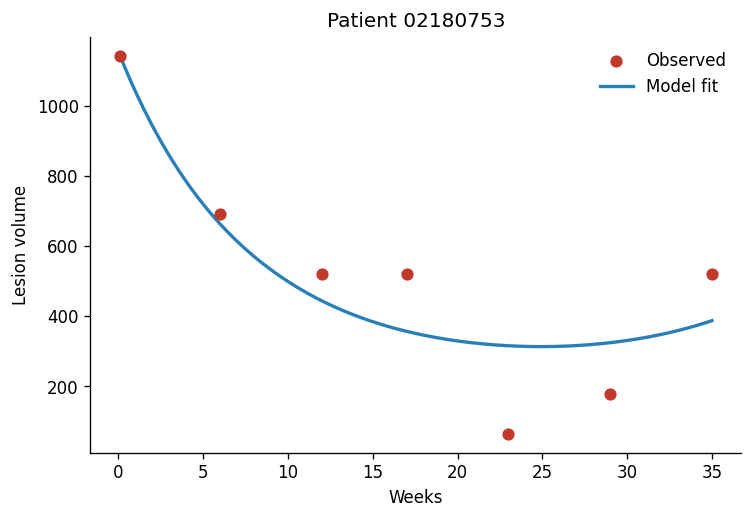

In [8]:
# --- Plot any patient by hash or index ---
def plot_patient(patient_id, df, results_df):
    pt = df[df["Pt_hashID"] == patient_id].sort_values("T_weeks")
    t, v = pt["T_weeks"].values, pt["Lesion_vol"].values
    row = results_df[results_df["patient"] == patient_id].iloc[0]

    t_smooth = np.linspace(t.min(), t.max(), 200)
    fitted = simulate(t_smooth, row["r"], row["k"], row["k_elim"], T0=v[0])

    fig, ax = plt.subplots(figsize=(7,4.5), dpi=120)
    ax.scatter(t, v, color='#c0392b', label='Observed', zorder=3, s=40)
    ax.plot(t_smooth, fitted, color='#2980b9', label='Model fit', linewidth=2)
    ax.set_xlabel('Weeks'); ax.set_ylabel('Lesion volume')
    ax.set_title(f'Patient {patient_id[:8]}')
    ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
    plt.show()

plot_patient(patients[0], df, results_df)

## 1. Question & Hypothesis

## 2. Model Formulation

## 3. Implementation

## 4. Baseline Simulation

## 7. Interpretation

## 8. Limitations